Environment & imports

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

plt.rcParams["figure.figsize"] = (8, 6)

# Connect DuckDB (in-memory, fast, no data loading)
con = duckdb.connect(database=":memory:")

Sanity check all files

In [2]:
files = [
    "blocks.parquet",
    "posts.parquet",
    "profiles.parquet",
    "follows.parquet",
    "likes.parquet",
    "reposts.parquet",
    "lists.parquet",
    "list_items.parquet",
    "list_blocks.parquet",
]

def inspect_parquet(path):
    q = f"""
    SELECT COUNT(*) AS rows
    FROM read_parquet('{path}')
    """
    rows = con.execute(q).fetchone()[0]
    print(f"\n {path}")
    print(f"Rows: {rows:,}")
    
    schema = con.execute(f"DESCRIBE SELECT * FROM read_parquet('{path}')").fetchdf()
    print(schema)

for f in files:
    inspect_parquet(f)



 blocks.parquet
Rows: 78,287,665
      column_name column_type null   key default extra
0          did_id      BIGINT  YES  None    None  None
1    created_date        DATE  YES  None    None  None
2  subject_did_id      BIGINT  YES  None    None  None

 posts.parquet
Rows: 812,390,294
           column_name column_type null   key default extra
0               did_id      BIGINT  YES  None    None  None
1         created_date        DATE  YES  None    None  None
2               labels        JSON  YES  None    None  None
3            languages        JSON  YES  None    None  None
4    reply_root_did_id      BIGINT  YES  None    None  None
5  reply_parent_did_id      BIGINT  YES  None    None  None

 profiles.parquet
Rows: 2,050,745
    column_name column_type null   key default extra
0        did_id      BIGINT  YES  None    None  None
1  created_date        DATE  YES  None    None  None
2        labels        JSON  YES  None    None  None

 follows.parquet
Rows: 1,009,328,631
      c

Define  core population

In [3]:
START_DATE = "2024-08-15"  # 2 weeks before
END_DATE   = "2024-09-15"  # 2 weeks after

Explore activity overtime

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

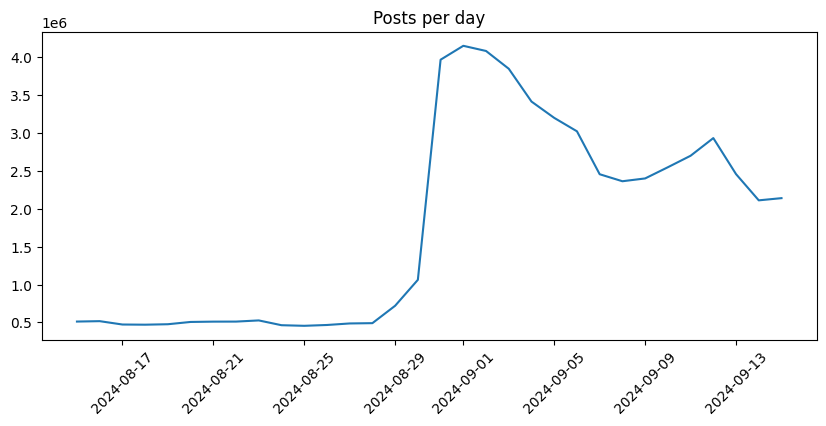

In [19]:
posts_daily = con.execute(f"""
    SELECT created_date, COUNT(*) AS posts
    FROM read_parquet('posts.parquet')
    WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
    GROUP BY created_date
    ORDER BY created_date
""").fetchdf()

plt.figure(figsize=(10,4))
plt.plot(posts_daily["created_date"], posts_daily["posts"])
plt.title("Posts per day")
plt.xticks(rotation=45)
plt.show()


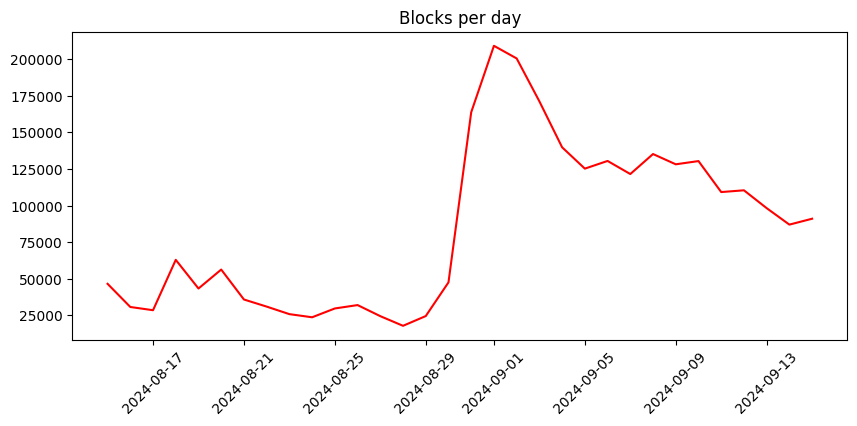

In [20]:
blocks_daily = con.execute(f"""
    SELECT created_date, COUNT(*) AS blocks
    FROM read_parquet('blocks.parquet')
    WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
    GROUP BY created_date
    ORDER BY created_date
""").fetchdf()

plt.figure(figsize=(10,4))
plt.plot(blocks_daily["created_date"], blocks_daily["blocks"], color="red")
plt.title("Blocks per day")
plt.xticks(rotation=45)
plt.show()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

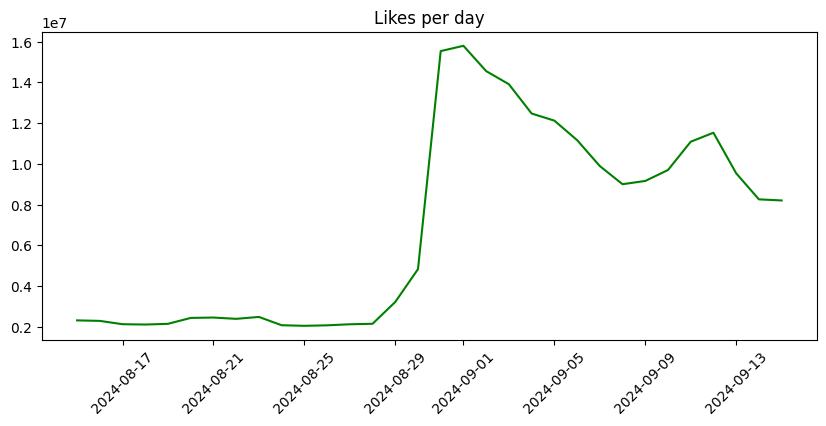

In [21]:
likes_daily = con.execute(f"""
    SELECT created_date, COUNT(*) AS likes
    FROM read_parquet('likes.parquet')
    WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
    GROUP BY created_date
    ORDER BY created_date
""").fetchdf()

plt.figure(figsize=(10,4))
plt.plot(likes_daily["created_date"], likes_daily["likes"], color="green")
plt.title("Likes per day")
plt.xticks(rotation=45)
plt.show()


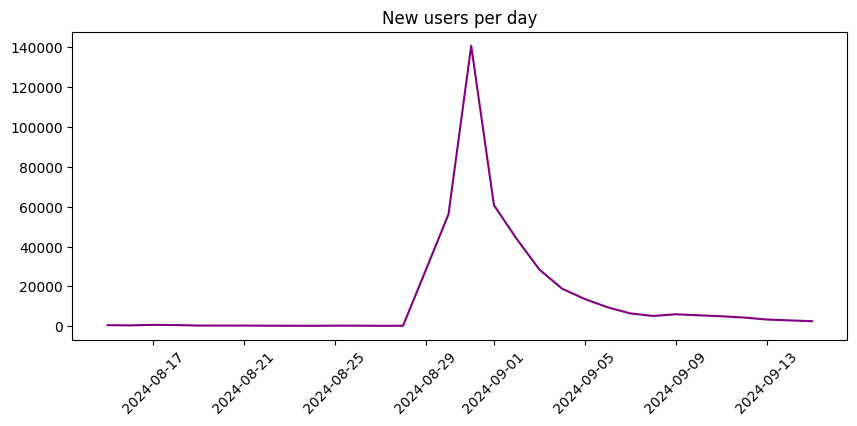

In [22]:
new_users = con.execute(f"""
    SELECT created_date, COUNT(*) AS new_users
    FROM read_parquet('profiles.parquet')
    WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
    GROUP BY created_date
    ORDER BY created_date
""").fetchdf()

plt.figure(figsize=(10,4))
plt.plot(new_users["created_date"], new_users["new_users"], color="purple")
plt.title("New users per day")
plt.xticks(rotation=45)
plt.show()


User-level correlations

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

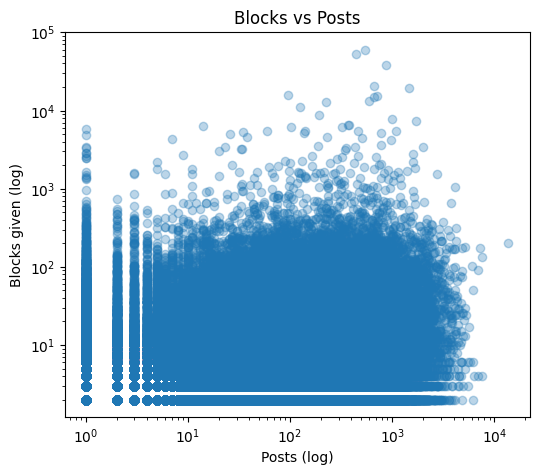

In [23]:
blocks_posts = con.execute(f"""
    SELECT
        b.did_id,
        b.blocks_given,
        COALESCE(p.posts, 0) AS posts
    FROM (
        SELECT did_id, COUNT(*) AS blocks_given
        FROM read_parquet('blocks.parquet')
        WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
        GROUP BY did_id
    ) b
    LEFT JOIN (
        SELECT did_id, COUNT(*) AS posts
        FROM read_parquet('posts.parquet')
        WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
        GROUP BY did_id
    ) p USING (did_id)
""").fetchdf()

plt.figure(figsize=(6,5))
plt.scatter(blocks_posts["posts"] + 1, blocks_posts["blocks_given"] + 1, alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Posts (log)")
plt.ylabel("Blocks given (log)")
plt.title("Blocks vs Posts")
plt.show()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

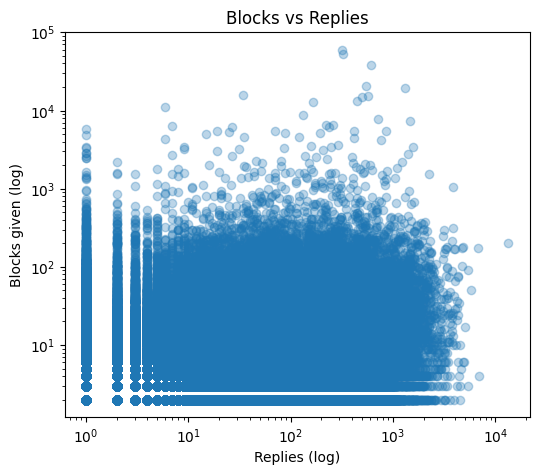

In [24]:
blocks_replies = con.execute(f"""
    SELECT
        b.did_id,
        b.blocks_given,
        COALESCE(r.replies, 0) AS replies
    FROM (
        SELECT did_id, COUNT(*) AS blocks_given
        FROM read_parquet('blocks.parquet')
        WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
        GROUP BY did_id
    ) b
    LEFT JOIN (
        SELECT did_id, COUNT(*) AS replies
        FROM read_parquet('posts.parquet')
        WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
          AND reply_parent_did_id IS NOT NULL
        GROUP BY did_id
    ) r USING (did_id)
""").fetchdf()

plt.figure(figsize=(6,5))
plt.scatter(blocks_replies["replies"] + 1, blocks_replies["blocks_given"] + 1, alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Replies (log)")
plt.ylabel("Blocks given (log)")
plt.title("Blocks vs Replies")
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

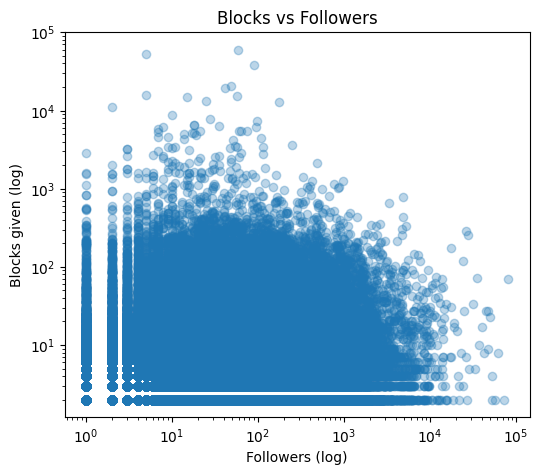

In [26]:
blocks_followers = con.execute(f"""
    SELECT
        b.did_id,
        b.blocks_given,
        COALESCE(f.followers, 0) AS followers
    FROM (
        SELECT did_id, COUNT(*) AS blocks_given
        FROM read_parquet('blocks.parquet')
        WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
        GROUP BY did_id
    ) b
    LEFT JOIN (
        SELECT subject_did_id AS did_id, COUNT(*) AS followers
        FROM read_parquet('follows.parquet')
        WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
        GROUP BY subject_did_id
    ) f USING (did_id)
""").fetchdf()

plt.figure(figsize=(6,5))
plt.scatter(blocks_followers["followers"] + 1, blocks_followers["blocks_given"] + 1, alpha=0.3)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Followers (log)")
plt.ylabel("Blocks given (log)")
plt.title("Blocks vs Followers")
plt.show()


Network graph set up
for blocking analysis / prediction, a user is useful if:

They produce signal (activity + interactions) and
They participate in conflict dynamics (blocks, replies, etc.)

So we want users who are:

    active enough

    exposed to interactions

    involved in blocks (given or received)

Not bots, not one-shot accounts, not silent lurkers

In [39]:
BLOCKS = "blocks.parquet"
POSTS  = "posts.parquet"

# -----------------------------
# Parameters
# -----------------------------
START_DATE = "2024-08-15"
END_DATE   = "2024-09-15"

MIN_BLOCKS_GIVEN = 10
MIN_POSTS = 20
MIN_REPLIES = 5

# -----------------------------
# DuckDB connection
# -----------------------------
con = duckdb.connect(database=":memory:")

In [40]:
# -----------------------------
# 1. Active blockers
# -----------------------------
con.execute(f"""
CREATE TEMP TABLE active_blockers AS
SELECT did_id,
       COUNT(*) AS blocks_given
FROM read_parquet('{BLOCKS}')
WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
GROUP BY did_id
HAVING COUNT(*) >= {MIN_BLOCKS_GIVEN}
""")

In [41]:
# -----------------------------
# 2. Active posters
# -----------------------------
con.execute(f"""
CREATE TEMP TABLE active_posters AS
SELECT did_id,
       COUNT(*) AS post_count
FROM read_parquet('{POSTS}')
WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
GROUP BY did_id
HAVING COUNT(*) >= {MIN_POSTS}
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [42]:
# -----------------------------
# 3. Active repliers
# -----------------------------
con.execute(f"""
CREATE TEMP TABLE active_repliers AS
SELECT did_id,
       COUNT(*) AS reply_count
FROM read_parquet('{POSTS}')
WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
  AND reply_parent_did_id IS NOT NULL
GROUP BY did_id
HAVING COUNT(*) >= {MIN_REPLIES}
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [43]:
# -----------------------------
# 4. Final user set (intersection)
# -----------------------------
con.execute("""
CREATE TEMP TABLE selected_users AS
SELECT b.did_id
FROM active_blockers b
JOIN active_posters p USING (did_id)
JOIN active_repliers r USING (did_id)
""")

In [44]:
# -----------------------------
# 5. Final block edges (graph)
# -----------------------------
blocks_graph = con.execute(f"""
SELECT
    did_id AS blocker,
    subject_did_id AS blocked
FROM read_parquet('{BLOCKS}')
WHERE created_date BETWEEN '{START_DATE}' AND '{END_DATE}'
  AND did_id IN (SELECT did_id FROM selected_users)
  AND subject_did_id IN (SELECT did_id FROM selected_users)
""").fetchdf()



In [ ]:
# -----------------------------
# 6. Diagnostics
# -----------------------------
num_nodes = con.execute("""
SELECT COUNT(DISTINCT did_id) FROM selected_users
""").fetchone()[0]

num_edges = len(blocks_graph)

print("Final graph stats")
print("------------------")
print(f"Nodes: {num_nodes:,}")
print(f"Edges: {num_edges:,}")
print(f"Time window: {START_DATE} → {END_DATE}")

blocks_graph.head()


Final graph stats
------------------
Nodes: 33,901
Edges: 182,478
Time window: 2024-08-15 → 2024-09-15


,blocker,blocked
0,109144,29745745
1,109144,17362021
2,109144,5096582
3,109144,21733425
4,109144,13550451


Restrict blocks to this user set

Build the block network

In [46]:
import networkx as nx

# blocks_filtered is your final filtered DataFrame
# columns: blocker, blocked

G = nx.DiGraph()

# Add edges
for _, row in blocks_graph.iterrows():
    a = row["blocker"]
    b = row["blocked"]
    if G.has_edge(a, b):
        G[a][b]["weight"] += 1
    else:
        G.add_edge(a, b, weight=1)

print("Graph built")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Graph built
Nodes: 29803
Edges: 182474


In [48]:
# Degree stats
in_degrees = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

print("Avg blocks given:", sum(out_degrees)/len(out_degrees))
print("Avg blocks received:", sum(in_degrees)/len(in_degrees))

# Strongly connected components
scc = list(nx.strongly_connected_components(G))
print("Number of SCCs:", len(scc))
print("Largest SCC size:", max(len(c) for c in scc))


Avg blocks given: 6.122672214206624
Avg blocks received: 6.122672214206624
Number of SCCs: 14331
Largest SCC size: 15434


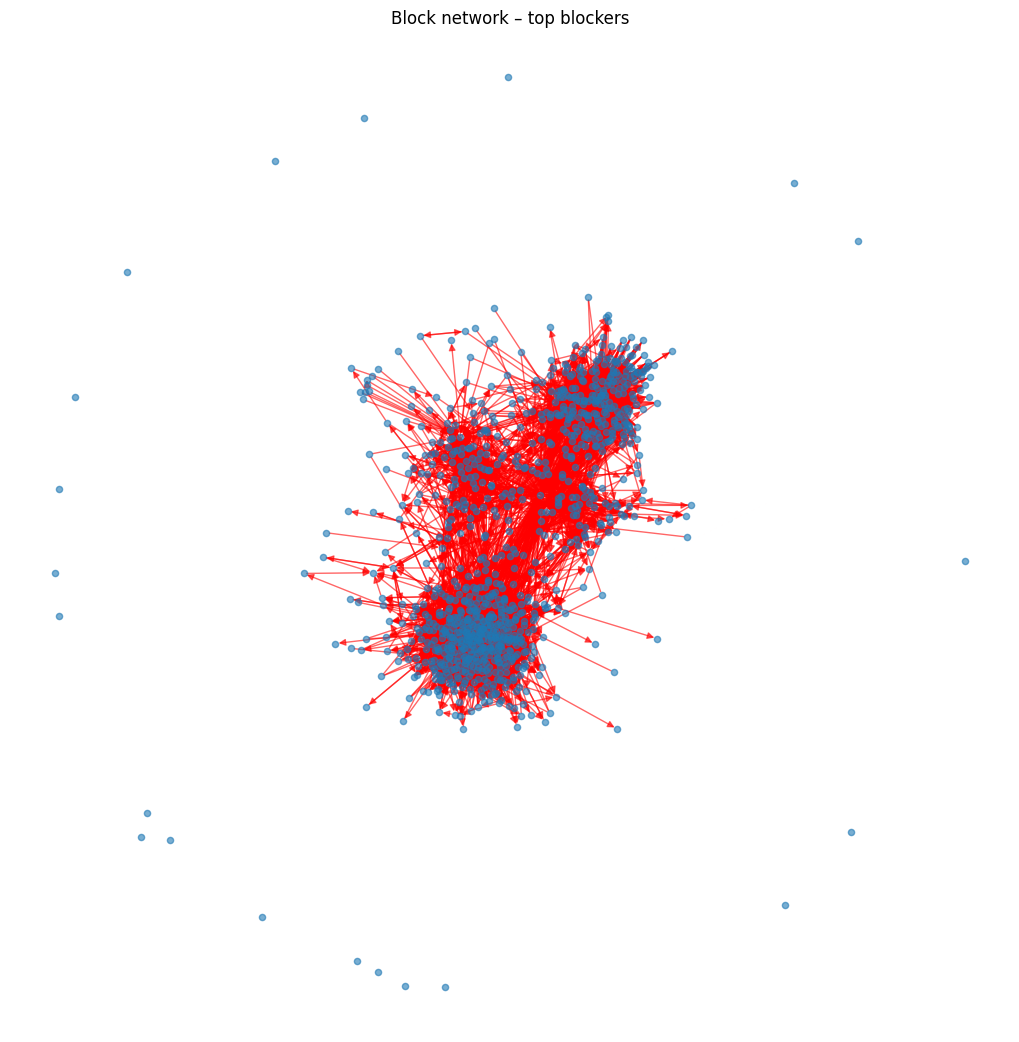

In [ ]:
# Top 1000 users by blocks given
top_blockers = sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:1000]
top_nodes = [u for u, _ in top_blockers]

H = G.subgraph(top_nodes)

plt.figure(figsize=(10,10))
pos = nx.spring_layout(H, k=0.3, seed=42)
nx.draw(
    H,
    pos,
    node_size=20,
    edge_color="red",
    alpha=0.6,
    with_labels=False
)
plt.title("Block network – top blockers")
plt.show()


In [54]:
pip install python-louvain

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9473 sha256=69f85d902230a9fa89695c67cd9eb744dac358610b79d2322cb225b0e12a5358
  Stored in directory: c:\users\marie\appdata\local\pip\cache\wheels\ee\52\54\7ecd0f1ebf5f5a8466f70a27ed2b94d20b955376879d6159c5
Successfully built python-louvain
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import community as community_louvain

In [ ]:
G_top = G.subgraph(top_nodes).copy()

# Convert to undirected for Louvain 
if isinstance(G_top, nx.DiGraph):
    G_u = nx.Graph()
    for u, v, data in G_top.edges(data=True):
        w = data.get("weight", 1.0)
        if G_u.has_edge(u, v):
            G_u[u][v]["weight"] += w
        else:
            G_u.add_edge(u, v, weight=w)
    # keep isolated nodes too
    G_u.add_nodes_from(G_top.nodes())
else:
    G_u = G_top.copy()

In [ ]:
# Louvain partition (node -> community_id)
partition = community_louvain.best_partition(G_u, weight="weight", random_state=42)

# Quick stats
from collections import Counter
sizes = Counter(partition.values())
print("Number of communities:", len(sizes))
print("Top community sizes:", sizes.most_common(10))

Number of communities: 27
Top community sizes: [(0, 264), (6, 238), (15, 215), (4, 154), (3, 97), (1, 11), (26, 1), (2, 1), (5, 1), (7, 1)]


(np.float64(-1.0968089159772634),
 np.float64(1.0748028390231013),
 np.float64(-1.0614306023134579),
 np.float64(1.0981633620149265))

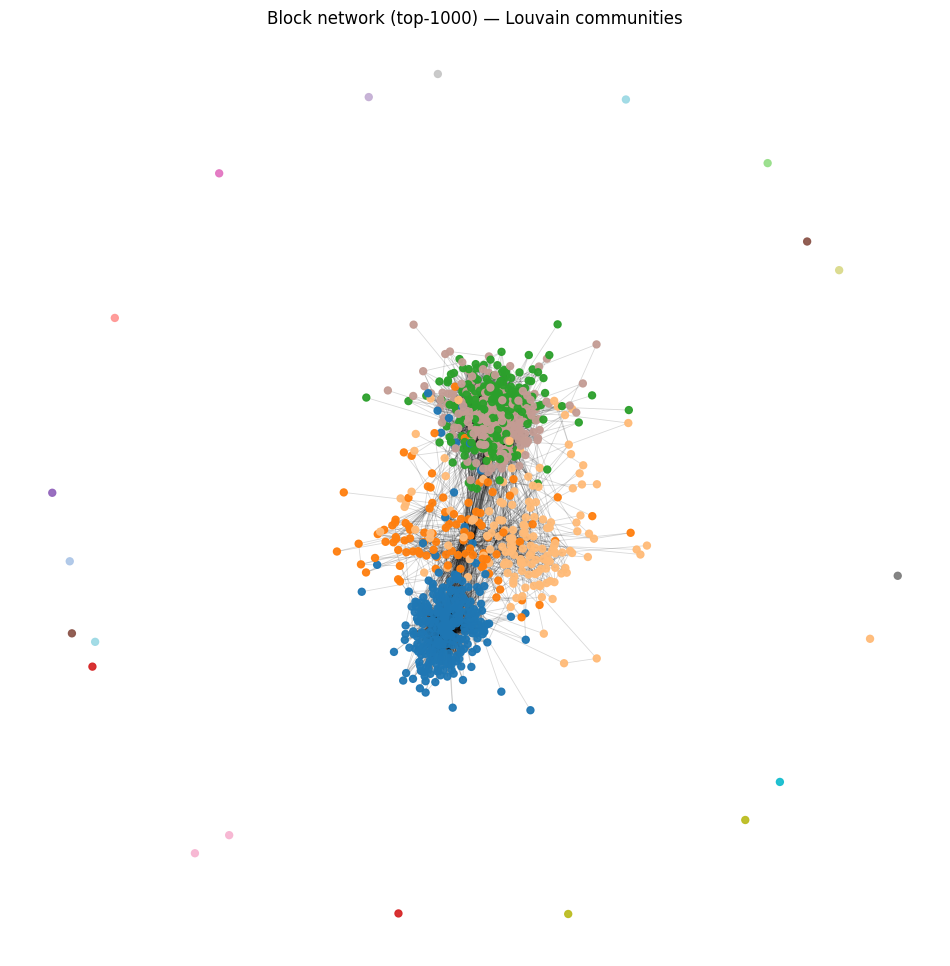

In [ ]:
# Layout + plot (color by community)
pos = nx.spring_layout(G_u, seed=42, k=0.25)

# Build a stable color mapping (community ids -> 0..K-1)
comm_ids = sorted(set(partition.values()))
comm_index = {c:i for i, c in enumerate(comm_ids)}
node_colors = [comm_index[partition[n]] for n in G_u.nodes()]

plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(G_u, pos, alpha=0.15, width=0.6)
nodes = nx.draw_networkx_nodes(
    G_u, pos,
    node_color=node_colors,
    cmap=plt.cm.tab20,  
    node_size=25,
    alpha=0.95
)

plt.title("Block network (top-1000) — Louvain communities")
plt.axis("off")

In [59]:
cbar = plt.colorbar(nodes, shrink=0.7)
cbar.set_label("Community index")
plt.show()

C:\Users\marie\AppData\Local\Temp\ipykernel_31404\40312445.py:1: UserWarning: Adding colorbar to a different Figure <Figure size 1200x1200 with 2 Axes> than <Figure size 800x600 with 0 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(nodes, shrink=0.7)


<Figure size 800x600 with 0 Axes>